# 01_EDA.ipynb

Exploratory Data Analysis untuk dataset AI Generated Human vs Authentic Human.

Notebook ini **hanya melakukan analisis** dan **tidak mengubah dataset**.

In [1]:
import tensorflow as tf
import numpy as np
import pandas as pd
import cv2
import matplotlib.pyplot as plt
from PIL import Image
from pathlib import Path
import imagehash

print("TensorFlow :", tf.__version__)
print("NumPy      :", np.__version__)
print("Pandas     :", pd.__version__)
print("OpenCV     :", cv2.__version__)

TensorFlow : 2.21.0
NumPy      : 2.4.6
Pandas     : 3.0.3
OpenCV     : 5.0.0


## Project Configuration

In [2]:
DATASET_PATH = Path("../dataset")
REAL_PATH = DATASET_PATH / "authentic-human-images"
AI_PATH = DATASET_PATH / "ai-generated-human-images"

REAL_IMAGES = list(REAL_PATH.glob("*"))
AI_IMAGES = list(AI_PATH.glob("*"))

print(f"Authentic : {len(REAL_IMAGES)}")
print(f"AI        : {len(AI_IMAGES)}")
print(f"Total     : {len(REAL_IMAGES)+len(AI_IMAGES)}")

Authentic : 740
AI        : 786
Total     : 1526


## Dataset Summary

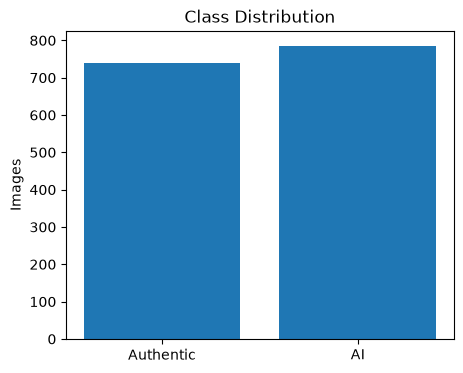

In [3]:
plt.figure(figsize=(5,4))
plt.bar(["Authentic","AI"],[len(REAL_IMAGES),len(AI_IMAGES)])
plt.ylabel("Images")
plt.title("Class Distribution")
plt.show()

## Build Metadata

In [4]:
records=[]

for label, folder in [("Authentic",REAL_PATH),("AI",AI_PATH)]:
    for file in sorted(folder.iterdir()):
        try:
            with Image.open(file) as img:
                w,h=img.size
                fmt=img.format
                mode=img.mode
            records.append({
                "filename":file.name,
                "label":label,
                "width":w,
                "height":h,
                "format":fmt,
                "mode":mode,
                "size_kb":round(file.stat().st_size/1024,2)
            })
        except Exception as e:
            print(file,e)

df=pd.DataFrame(records)
df.head()

,filename,label,width,height,format,mode,size_kb
0,#birthdayparty #partyinspo.jpg,Authentic,736,981,JPEG,RGB,45.12
1,#denmark #aarhus #selfie.jpg,Authentic,735,490,JPEG,RGB,37.49
2,#fyp.jpg,Authentic,736,475,JPEG,RGB,43.04
3,0.26907100_1666012003_poor-123.avif,Authentic,1200,900,AVIF,RGB,112.81
4,00a06e610f2d6fc2.jpg,Authentic,1024,683,JPEG,RGB,404.26


## Basic Information

In [5]:
display(df.info())
display(df.describe(include="all"))

<class 'pandas.DataFrame'>
RangeIndex: 1526 entries, 0 to 1525
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   filename  1526 non-null   str    
 1   label     1526 non-null   str    
 2   width     1526 non-null   int64  
 3   height    1526 non-null   int64  
 4   format    1526 non-null   str    
 5   mode      1526 non-null   str    
 6   size_kb   1526 non-null   float64
dtypes: float64(1), int64(2), str(4)
memory usage: 152.8 KB


None

,filename,label,width,height,format,mode,size_kb
count,1526,1526,1526.000000,1526.000000,1526,1526,1526.000000
unique,1526,2,NaN,NaN,5,3,NaN
top,#birthdayparty #partyinspo.jpg,AI,NaN,NaN,PNG,RGB,NaN
freq,1,786,NaN,NaN,769,1518,NaN
mean,NaN,NaN,1166.083879,1138.451507,NaN,NaN,1195.062765
std,NaN,NaN,524.528264,610.212536,NaN,NaN,1053.880449
min,NaN,NaN,192.000000,221.000000,NaN,NaN,6.300000
25%,NaN,NaN,736.000000,683.000000,NaN,NaN,100.835000
50%,NaN,NaN,1086.000000,1086.000000,NaN,NaN,1595.215000
75%,NaN,NaN,1448.000000,1448.000000,NaN,NaN,2145.647500


## Resolution Analysis

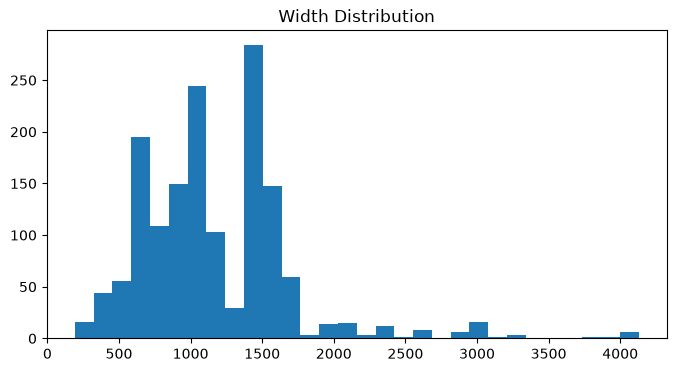

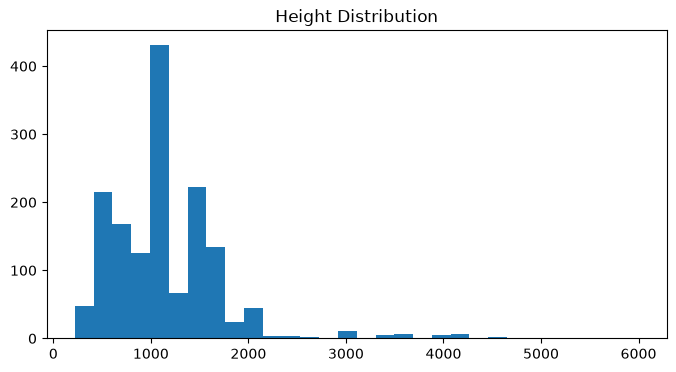

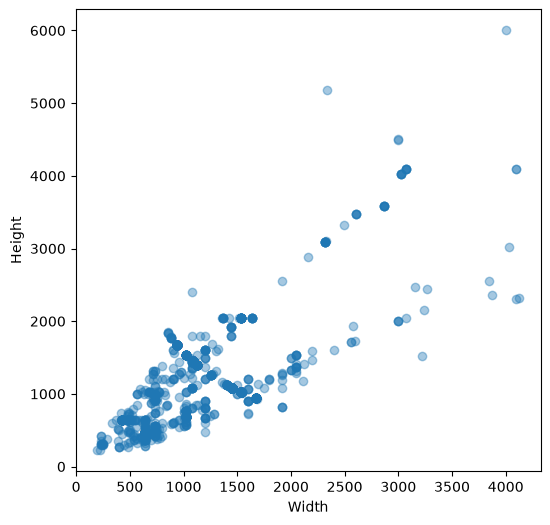

In [6]:
plt.figure(figsize=(8,4))
plt.hist(df["width"],bins=30)
plt.title("Width Distribution")
plt.show()

plt.figure(figsize=(8,4))
plt.hist(df["height"],bins=30)
plt.title("Height Distribution")
plt.show()

plt.figure(figsize=(6,6))
plt.scatter(df["width"],df["height"],alpha=0.4)
plt.xlabel("Width")
plt.ylabel("Height")
plt.show()

## Format, Color Mode, Aspect Ratio

format
PNG     769
JPEG    714
WEBP     30
AVIF     12
BMP       1
Name: count, dtype: int64

mode
RGB     1518
L          6
RGBA       2
Name: count, dtype: int64

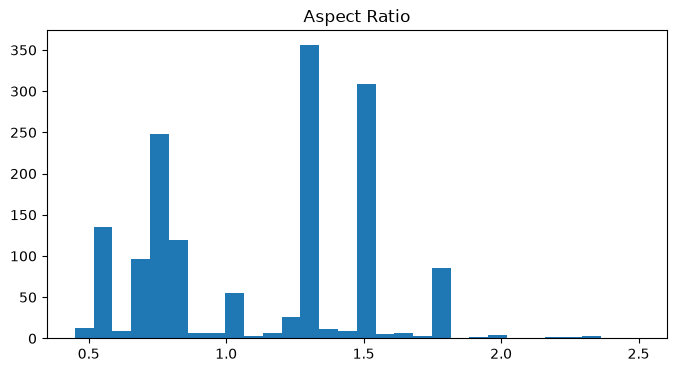

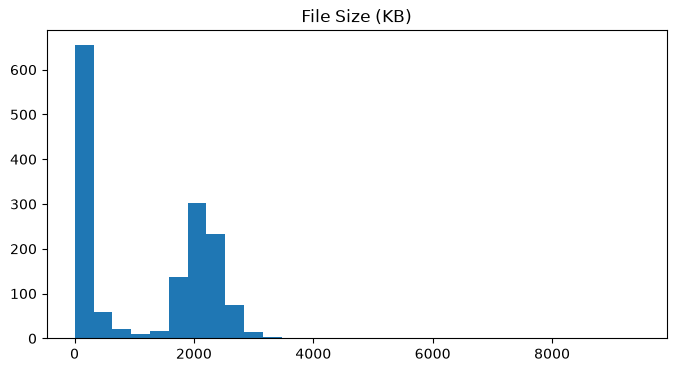

In [7]:
display(df["format"].value_counts())
display(df["mode"].value_counts())

df["aspect_ratio"]=df["width"]/df["height"]

plt.figure(figsize=(8,4))
plt.hist(df["aspect_ratio"],bins=30)
plt.title("Aspect Ratio")
plt.show()

plt.figure(figsize=(8,4))
plt.hist(df["size_kb"],bins=30)
plt.title("File Size (KB)")
plt.show()

## Corrupted Image Check

In [8]:
corrupted=[]
for folder in [REAL_PATH,AI_PATH]:
    for file in folder.iterdir():
        try:
            with Image.open(file) as img:
                img.verify()
        except Exception as e:
            corrupted.append({"file":file.name,"error":str(e)})

corrupted_df=pd.DataFrame(corrupted)
print("Corrupted:",len(corrupted_df))
corrupted_df.head()

Corrupted: 0


""


## Duplicate Check

In [9]:
hash_map={}
duplicates=[]

for folder in [REAL_PATH,AI_PATH]:
    for file in folder.iterdir():
        try:
            with Image.open(file) as img:
                h=str(imagehash.average_hash(img))
            if h in hash_map:
                duplicates.append({
                    "original":hash_map[h],
                    "duplicate":file.name
                })
            else:
                hash_map[h]=file.name
        except Exception:
            pass

duplicates_df=pd.DataFrame(duplicates)
print("Duplicate:",len(duplicates_df))
duplicates_df.head()

Duplicate: 1


,original,duplicate
0,"ChatGPT Image Jul 2, 2026, 01_36_58 PM.png","ChatGPT Image Jul 6, 2026, 03_52_06 PM.png"


## Sample Images

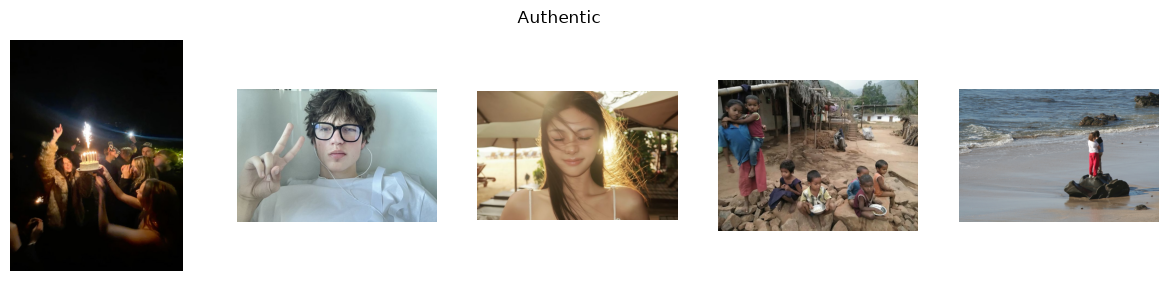

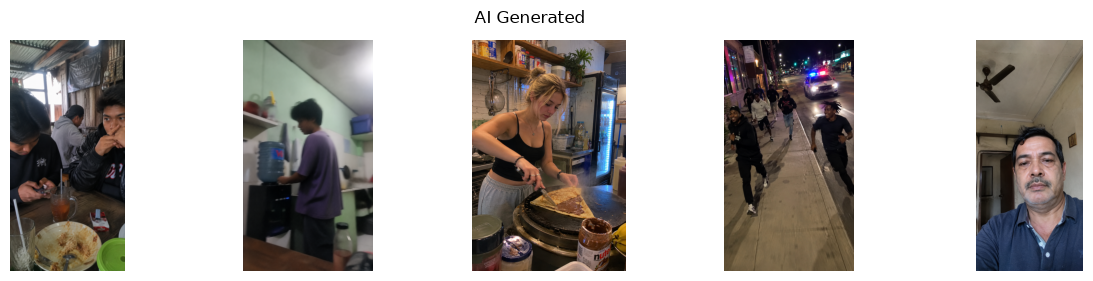

In [10]:
def show_samples(folder,title,n=5):
    files=sorted(list(folder.glob("*")))[:n]
    plt.figure(figsize=(15,3))
    for i,f in enumerate(files):
        plt.subplot(1,n,i+1)
        plt.imshow(Image.open(f))
        plt.axis("off")
    plt.suptitle(title)
    plt.show()

show_samples(REAL_PATH,"Authentic")
show_samples(AI_PATH,"AI Generated")